# GDELT Filtering & Data Quality

[GDELT](https://www.gdeltproject.org/) (Global Database of Events,
Language, and Tone) is a free, open project that monitors news worldwide —
roughly **400,000+ English-language articles per day** from the open web.
All data is freely available on **Google BigQuery**.

To use GDELT for firm-level finance, we filter its firehose down to
articles mentioning S&P 500 companies. We upload a small lookup table
(~4,500 rows) to BigQuery and **JOIN server-side** against the GKG
(Global Knowledge Graph) table on normalized company names. The full
query and post-processing logic are in `pull_gdelt_sp500_headlines.py`.

This notebook examines the **quality** of that filtering: how much data
survives each filter stage, which companies match, and where false
positives appear.

## 1. Setup & Data Loading

In [1]:
from datetime import datetime
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
from google.cloud import bigquery
from pull_gdelt_sp500_headlines import (
    GDELT_SP500_DIR,
    SAMPLE_MONTH,
    filter_to_month,
    load_gdelt_sp500_headlines,
)
from settings import config

DATA_DIR = Path(config("DATA_DIR"))
GCP_PROJECT = config("GCP_PROJECT")

client = bigquery.Client(project=GCP_PROJECT)

# Derive date range from the sample month
_sm_dt = datetime.strptime(SAMPLE_MONTH, "%Y-%m").date()
SAMPLE_START = _sm_dt.strftime("%Y-%m-%d")
if _sm_dt.month == 12:
    SAMPLE_END = _sm_dt.replace(year=_sm_dt.year + 1, month=1, day=1).strftime(
        "%Y-%m-%d"
    )
else:
    SAMPLE_END = _sm_dt.replace(month=_sm_dt.month + 1, day=1).strftime("%Y-%m-%d")

/opt/homebrew/Caskroom/mambaforge/base/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.14) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/opt/homebrew/Caskroom/mambaforge/base/lib/python3.10/site-packages/google/auth/_default.py:114: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


In [2]:
gd_sp = filter_to_month(load_gdelt_sp500_headlines(), SAMPLE_MONTH).collect()
lookup = pd.read_parquet(DATA_DIR / "sp500_names_lookup.parquet")

print(f"Sample month: {SAMPLE_MONTH} ({SAMPLE_START} to {SAMPLE_END})")
print(f"S&P 500-filtered headlines (1 month): {len(gd_sp):>10,}")
print(f"S&P 500 names lookup rows:            {len(lookup):>10,}")

Sample month: 2025-01 (2025-01-01 to 2025-02-01)
S&P 500-filtered headlines (1 month):    447,910
S&P 500 names lookup rows:                 4,530


---
## Key Result: RavenPack Headline Coverage

In [3]:
_cw = pl.read_parquet(DATA_DIR / "newswire_ravenpack_crosswalk.parquet")

from pull_free_newswires import load_newswire_headlines as _load_nw

_nw_total_urls = (
    _load_nw()
    .with_columns(pl.col("date").str.to_date())
    .filter(
        (pl.col("date") >= _cw["date"].min()) & (pl.col("date") <= _cw["date"].max())
    )
    .select(pl.col("source_url").n_unique())
    .collect()
    .item()
)
_nw_matched_urls = _cw["nw_source_url"].n_unique()
_nw_match_rate = _nw_matched_urls / _nw_total_urls * 100

_rp_full = (
    pl.scan_parquet(DATA_DIR / "ravenpack_djpr.parquet")
    .with_columns(pl.col("timestamp_utc").cast(pl.Date).alias("date"))
    .filter(
        (pl.col("date") >= _cw["date"].min()) & (pl.col("date") <= _cw["date"].max())
    )
    .select("rp_story_id")
)
_rp_total_stories = _rp_full.select(pl.col("rp_story_id").n_unique()).collect().item()
_rp_matched_stories = _cw["rp_story_id"].n_unique()
_rp_match_rate = _rp_matched_stories / _rp_total_stories * 100

pl.DataFrame({
    "metric": [
        "RP headlines matched",
        "NW headlines matched",
        "GDELT match rate",
        "Crosswalk pairs",
        "Date range",
    ],
    "value": [
        f"{_rp_match_rate:.1f}% ({_rp_matched_stories:,} / {_rp_total_stories:,})",
        f"{_nw_match_rate:.1f}% ({_nw_matched_urls:,} / {_nw_total_urls:,})",
        "~7% (different source ecosystems)",
        f"{len(_cw):,}",
        f"{_cw['date'].min()} to {_cw['date'].max()} ({_cw['date'].n_unique():,} dates)",
    ],
})

metric,value
str,str
"""RP headlines matched""","""2.9% (509,932 / 17,636,011)"""
"""NW headlines matched""","""22.5% (532,609 / 2,363,887)"""
"""GDELT match rate""","""~7% (different source ecosyste…"
"""Crosswalk pairs""","""533,265"""
"""Date range""","""2010-03-18 to 2026-02-28 (3,83…"


### Short normalized names — high false-positive risk

The lookup table normalizes company names by lowercasing, stripping
punctuation, and removing corporate suffixes (inc, corp, ltd, etc.).
Names shorter than 5 characters are already filtered out, but some
boundary cases remain:

In [4]:
short_names = lookup[lookup["comnam_norm"].str.len() <= 6].copy()
short_names = short_names.sort_values("comnam_norm").drop_duplicates("comnam_norm")

print(f"Lookup entries with normalized name <= 6 characters: {len(short_names)}")
print("\nExamples of short normalized names:\n")
for _, row in short_names.head(20).iterrows():
    ticker = row.ticker if pd.notna(row.ticker) else "N/A"
    print(f'  "{row.comnam}"  →  "{row.comnam_norm}"  (ticker={ticker})')

Lookup entries with normalized name <= 6 characters: 413

Examples of short normalized names:

  "A C F INDUSTRIES INC"  →  "a c f"  (ticker=N/A)
  "A D T CORP"  →  "a d t"  (ticker=ADT)
  "A E S CORP"  →  "a e s"  (ticker=AESC)
  "A M F INC"  →  "a m f"  (ticker=AMF)
  "A M P INC"  →  "a m p"  (ticker=AMP)
  "A P A CORP"  →  "a p a"  (ticker=APA)
  "A R A SERVICES INC"  →  "a r a"  (ticker=ARA)
  "A S A LTD"  →  "a s a"  (ticker=ASA)
  "A T F INC"  →  "a t f"  (ticker=N/A)
  "A T I INC"  →  "a t i"  (ticker=ATI)
  "A T & T INC"  →  "a t t"  (ticker=T)
  "A V C CORP"  →  "a v c"  (ticker=VIS)
  "ABBVIE INC"  →  "abbvie"  (ticker=ABBV)
  "ADIENT PLC"  →  "adient"  (ticker=ADNT)
  "ADOBE SYSTEMS INC"  →  "adobe"  (ticker=ADBE)
  "AEICOR INC"  →  "aeicor"  (ticker=AEIC)
  "AETNA INC"  →  "aetna"  (ticker=AET)
  "AFLAC INC"  →  "aflac"  (ticker=AFL)
  "INTERNATIONAL AGRIC CORP"  →  "agric"  (ticker=N/A)
  "AIRBNB INC"  →  "airbnb"  (ticker=ABNB)


---
## 2. The Filtering Funnel

Each filter in our BigQuery query cuts the data dramatically. We measure
each stage with cheap `COUNT(*)` queries against the sample month.

In [5]:
funnel_queries = {
    "1. All GKG rows (in partition window)": f"""
        SELECT COUNT(*) AS n
        FROM `gdelt-bq.gdeltv2.gkg_partitioned`
        WHERE _PARTITIONTIME >= TIMESTAMP('{SAMPLE_START}')
          AND _PARTITIONTIME < TIMESTAMP('{SAMPLE_END}')
    """,
    "2. Has headline (<PAGE_TITLE>)": f"""
        SELECT COUNT(*) AS n
        FROM `gdelt-bq.gdeltv2.gkg_partitioned`
        WHERE _PARTITIONTIME >= TIMESTAMP('{SAMPLE_START}')
          AND _PARTITIONTIME < TIMESTAMP('{SAMPLE_END}')
          AND Extras LIKE '%<PAGE_TITLE>%'
    """,
    "3. English only (TranslationInfo IS NULL)": f"""
        SELECT COUNT(*) AS n
        FROM `gdelt-bq.gdeltv2.gkg_partitioned`
        WHERE _PARTITIONTIME >= TIMESTAMP('{SAMPLE_START}')
          AND _PARTITIONTIME < TIMESTAMP('{SAMPLE_END}')
          AND Extras LIKE '%<PAGE_TITLE>%'
          AND TranslationInfo IS NULL
    """,
    "4. Has V2Organizations": f"""
        SELECT COUNT(*) AS n
        FROM `gdelt-bq.gdeltv2.gkg_partitioned`
        WHERE _PARTITIONTIME >= TIMESTAMP('{SAMPLE_START}')
          AND _PARTITIONTIME < TIMESTAMP('{SAMPLE_END}')
          AND Extras LIKE '%<PAGE_TITLE>%'
          AND TranslationInfo IS NULL
          AND V2Organizations IS NOT NULL
          AND V2Organizations != ''
    """,
}

print(f"Filtering funnel for GDELT GKG ({SAMPLE_START} to {SAMPLE_END}):\n")
print(f"{'Stage':<45} {'Rows':>12} {'% of prev':>10}")
print("-" * 69)

funnel_counts = {}
prev_n = None
for label, query in funnel_queries.items():
    result = client.query(query).result()
    n = list(result)[0]["n"]
    funnel_counts[label] = n
    pct = f"{n / prev_n * 100:.1f}%" if prev_n else ""
    print(f"{label:<45} {n:>12,} {pct:>10}")
    prev_n = n

# Add the final stage from the local data
n_sp500 = len(gd_sp)
pct_sp500 = f"{n_sp500 / prev_n * 100:.1f}%"
funnel_counts["5. Matches S&P 500 company name"] = n_sp500
print(f"{'5. Matches S&P 500 company name':<45} {n_sp500:>12,} {pct_sp500:>10}")

Filtering funnel for GDELT GKG (2025-01-01 to 2025-02-01):

Stage                                                 Rows  % of prev
---------------------------------------------------------------------


1. All GKG rows (in partition window)           10,858,289           


2. Has headline (<PAGE_TITLE>)                  10,858,289     100.0%


3. English only (TranslationInfo IS NULL)        4,024,816      37.1%


4. Has V2Organizations                           2,839,583      70.6%
5. Matches S&P 500 company name                    447,910      15.8%


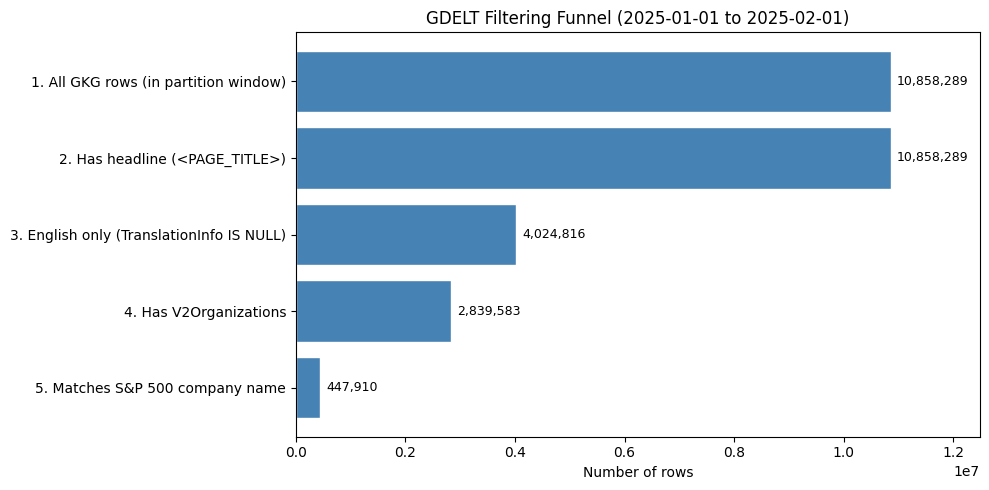


Total reduction: 10,858,289 → 447,910 (24× smaller)


In [6]:
labels = list(funnel_counts.keys())
counts = list(funnel_counts.values())

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(labels[::-1], counts[::-1], color="steelblue", edgecolor="white")

for bar, count in zip(bars, counts[::-1]):
    ax.text(
        bar.get_width() + max(counts) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{count:,}",
        va="center",
        fontsize=9,
    )

ax.set_xlabel("Number of rows")
ax.set_title(f"GDELT Filtering Funnel ({SAMPLE_START} to {SAMPLE_END})")
ax.set_xlim(0, max(counts) * 1.15)
fig.tight_layout()
plt.show()

total_reduction = counts[0] / counts[-1] if counts[-1] > 0 else float("inf")
print(
    f"\nTotal reduction: {counts[0]:,} → {counts[-1]:,} ({total_reduction:.0f}× smaller)"
)

---
## 3. Coverage: What Matched

In [7]:
matched_companies = (
    gd_sp.group_by("matched_company", "ticker", "permno")
    .agg(pl.len().alias("n_headlines"))
    .sort("n_headlines", descending=True)
)

n_permnos = gd_sp["permno"].n_unique()
n_companies = matched_companies.height

print(f"Distinct PERMNOs matched:   {n_permnos}")
print(f"Distinct (company, ticker): {n_companies}")

Distinct PERMNOs matched:   934
Distinct (company, ticker): 1362


In [8]:
print("Top 25 companies by headline count:\n")
for row in matched_companies.head(25).iter_rows():
    company, ticker, permno, n = row
    ticker = ticker if ticker is not None else "N/A"
    print(f"  {n:>6,}  {ticker:<8s}  {company}")

Top 25 companies by headline count:

  157,417  USBC      UNITED STATES BANCORP
  47,019  FB        FACEBOOK INC
  25,108  TWTR      TWITTER INC
  23,139  NFLX      NETFLIX INC
  16,981  NDAQ      NASDAQ INC
   8,124  MSFT      MICROSOFT CORP
   7,854  GOOG      GOOGLE INC
   7,791  GOOG      GOOGLE INC
   7,435  NVDA      NVIDIA CORP
   7,264  GOOGL     GOOGLE INC
   7,201  NYK       NEW YORK TIMES CO
   6,938  NYT       NEW YORK TIMES CO
   5,287  WMT       WALMART INC
   5,250  AAL       AMERICAN AIRLINES GROUP INC
   4,735  ETN       EATON CORP
   4,654  ETN       EATON CORP PLC
   4,635  JPM       JPMORGAN CHASE & CO
   4,594  GS        GOLDMAN SACHS GROUP INC
   4,122  MS        MORGAN STANLEY GROUP INC
   3,251  WBR       WARNER BROS CO
   2,662  N/A       BOEING CO
   2,580  BA        BOEING CO
   2,408  C         CITIGROUP INC
   2,330  SBUX      STARBUCKS CORP
   2,284  CCI       CITIGROUP INC


---
## 4. The False Positive Problem

Our normalization strips corporate suffixes like "bancorp" and "corp".
This can produce generic names that match far too broadly — e.g.,
"UNITED STATES BANCORP" normalizes to "united states", matching every
US government entity in GDELT.

In [9]:
SUSPICIOUS_THRESHOLD = 20_000

company_counts = (
    gd_sp.group_by("matched_company")
    .agg(pl.len().alias("n"))
    .sort("n", descending=True)
)

top_offenders = company_counts.head(10).to_pandas()
lookup_map = lookup.drop_duplicates("comnam")[["comnam", "comnam_norm"]].set_index(
    "comnam"
)

print(f"{'Company':<35} {'Norm. Name':<25} {'Headlines':>10}")
print("-" * 72)
for _, row in top_offenders.iterrows():
    company = row["matched_company"]
    n = row["n"]
    norm = (
        lookup_map.loc[company, "comnam_norm"] if company in lookup_map.index else "?"
    )
    print(f"{company:<35} {norm:<25} {n:>10,}")

Company                             Norm. Name                 Headlines
------------------------------------------------------------------------
UNITED STATES BANCORP               united states                157,417
FACEBOOK INC                        facebook                      47,019
TWITTER INC                         twitter                       25,108
NETFLIX INC                         netflix                       23,139
GOOGLE INC                          google                        22,909
NASDAQ INC                          nasdaq                        16,981
NEW YORK TIMES CO                   new york times                14,139
MICROSOFT CORP                      microsoft                      8,124
NVIDIA CORP                         nvidia                         7,435
WALMART INC                         walmart                        5,287


### What false-positive headlines look like

In [10]:
fp_companies = ["UNITED STATES BANCORP"]
big_hitters = company_counts.filter(pl.col("n") > SUSPICIOUS_THRESHOLD)[
    "matched_company"
].to_list()
fp_companies = list(dict.fromkeys(fp_companies + big_hitters))

for company in fp_companies[:3]:
    subset = gd_sp.filter(pl.col("matched_company") == company)
    norm = (
        lookup_map.loc[company, "comnam_norm"] if company in lookup_map.index else "?"
    )
    print(f"\n{'=' * 80}")
    print(f'{company}  (normalizes to "{norm}")')
    print(f"{len(subset):,} headlines — sample of clearly irrelevant ones:")
    print(f"{'=' * 80}")
    sample = subset.sample(min(15, len(subset)), seed=42)
    for row in sample.iter_rows(named=True):
        matched_org = row.get("matched_org_raw", "")
        hl = row["headline"][:120]
        print(f"  org: {matched_org:<30s}  headline: {hl}")


UNITED STATES BANCORP  (normalizes to "united states")
157,417 headlines — sample of clearly irrelevant ones:
  org: United States                   headline: The Mill Food Recycler 2025 Review: How This Modern Composter Works
  org: United States                   headline: Prince William Republicans ring in the new Trump era
  org: United States                   headline: Rwanda-backed rebels enter outskirts of strategic city in what Congo calls 'declaration of war'
  org: United States                   headline: Could Texas Become a Geothermal Energy Hub?
  org: United States                   headline: Vance at March for Life: 'I Want More Babies in USA' | NewsTalk 590
  org: United States                   headline: Gallup Poll Shows How Majority of Americans Feel About Trump's Immigration Plans
  org: United States                   headline: Minor earthquake: M2.98 quake has struck near Little America in Wyoming
  org: United States                   headline: 8 Key Skills Pu

### Quantifying the damage

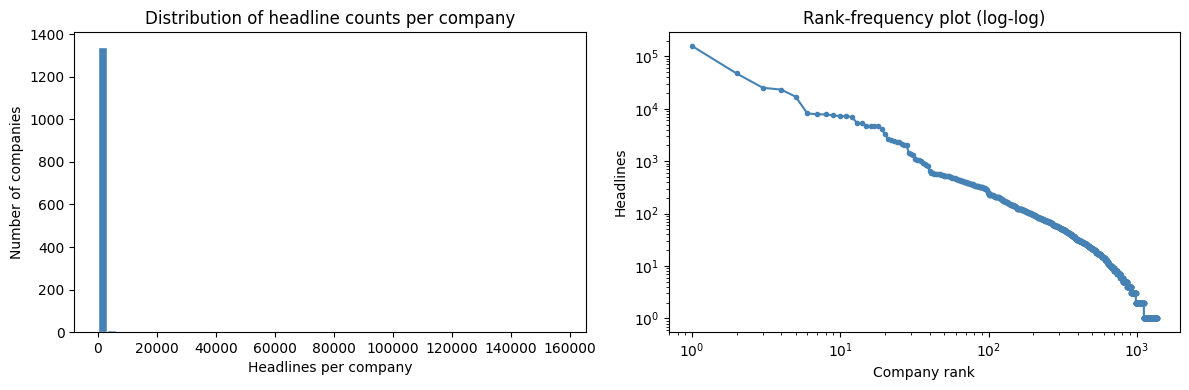

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

headline_counts = matched_companies["n_headlines"].to_numpy()

axes[0].hist(headline_counts, bins=50, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Headlines per company")
axes[0].set_ylabel("Number of companies")
axes[0].set_title("Distribution of headline counts per company")

ranked = np.sort(headline_counts)[::-1]
axes[1].loglog(range(1, len(ranked) + 1), ranked, "o-", markersize=3, color="steelblue")
axes[1].set_xlabel("Company rank")
axes[1].set_ylabel("Headlines")
axes[1].set_title("Rank-frequency plot (log-log)")

fig.tight_layout()
plt.show()

In [12]:
suspicious = matched_companies.filter(pl.col("n_headlines") > SUSPICIOUS_THRESHOLD)
suspicious_headlines = gd_sp.filter(
    pl.col("matched_company").is_in(suspicious["matched_company"])
)

n_suspicious = len(suspicious_headlines)
n_clean = len(gd_sp) - n_suspicious

print(f"Companies with > {SUSPICIOUS_THRESHOLD:,} headlines/month: {suspicious.height}")
print(
    f"Headlines from suspicious matches:    {n_suspicious:>8,} ({n_suspicious / len(gd_sp) * 100:.1f}%)"
)
print(
    f"Headlines from remaining companies:   {n_clean:>8,} ({n_clean / len(gd_sp) * 100:.1f}%)"
)

Companies with > 20,000 headlines/month: 4
Headlines from suspicious matches:     252,683 (56.4%)
Headlines from remaining companies:    195,227 (43.6%)


/var/folders/l3/tj6vb0ld2ys1h939jz0qrfrh0000gn/T/ipykernel_1710/1882465742.py:2: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  suspicious_headlines = gd_sp.filter(


In [13]:
print("Suspicious companies:\n")
for row in suspicious.iter_rows():
    company, ticker, permno, n = row
    ticker = ticker if ticker is not None else "N/A"
    print(f"  {n:>6,}  {ticker:<8s}  {company}")

Suspicious companies:

  157,417  USBC      UNITED STATES BANCORP
  47,019  FB        FACEBOOK INC
  25,108  TWTR      TWITTER INC
  23,139  NFLX      NETFLIX INC


---
## 5. Spot-Check: Do the Clean Matches Look Right?

In [14]:
clean_sp = gd_sp.filter(~pl.col("matched_company").is_in(suspicious["matched_company"]))

for company in [
    "APPLE INC",
    "MICROSOFT CORP",
    "NVIDIA CORP",
    "JPMORGAN CHASE & CO",
    "WALMART INC",
]:
    subset = clean_sp.filter(pl.col("matched_company") == company)
    if len(subset) == 0:
        continue
    print(f"\n{'=' * 70}")
    print(f"{company} — {len(subset):,} headlines")
    print(f"{'=' * 70}")
    for row in subset.sample(min(5, len(subset)), seed=42).iter_rows(named=True):
        print(f"  [{row['ticker']}] {row['headline'][:100]}")


APPLE INC — 564 headlines
  [AAPL] Expert: The problem is not China's economy, but those economists and their models
  [AAPL] Giant companies holding back US economy
  [AAPL] CCPA issues notice to Apple over iPhone performance issues, Telecom News, ET Telecom
  [AAPL] Yahoo Finance Review: Best Investment Websites to Research Stocks
  [AAPL] Chinese AI firm limits registration over 'malicious attacks'

MICROSOFT CORP — 8,124 headlines
  [MSFT] Trump warns of 'wake-up call' as low-cost Chinese AI jolts sector – The Frontier Post
  [MSFT] DOOM: The Dark Ages Rumored for Nintendo Switch 2 as Phil Spencer Teases More Multiplatform Support
  [MSFT] Trump 2nd term live updates: EPA temporarily pauses disbursement of federal aid
  [MSFT] Bluff Park's Robin Schultz to run for Hoover City Council third time
  [MSFT] How to Fix Corrupted Excel Files (.xls, .xlsx) - Top Recovery Solutions

NVIDIA CORP — 7,435 headlines
  [NVDA] DeepSeek Sparks Global Tech Selloff
  [NVDA] Donald Trump revokes Bi

/var/folders/l3/tj6vb0ld2ys1h939jz0qrfrh0000gn/T/ipykernel_1710/1150694679.py:1: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  clean_sp = gd_sp.filter(~pl.col("matched_company").is_in(suspicious["matched_company"]))


---
## 6. Full Data Lake Coverage

The sections above analyzed a single sample month. Now we load the
full data lake to see temporal coverage and company distribution
across all available months.

In [15]:
lf = load_gdelt_sp500_headlines()
df_full = lf.collect()
print(f"Total rows in data lake: {len(df_full):,}")

Total rows in data lake: 447,910


### Monthly headline counts

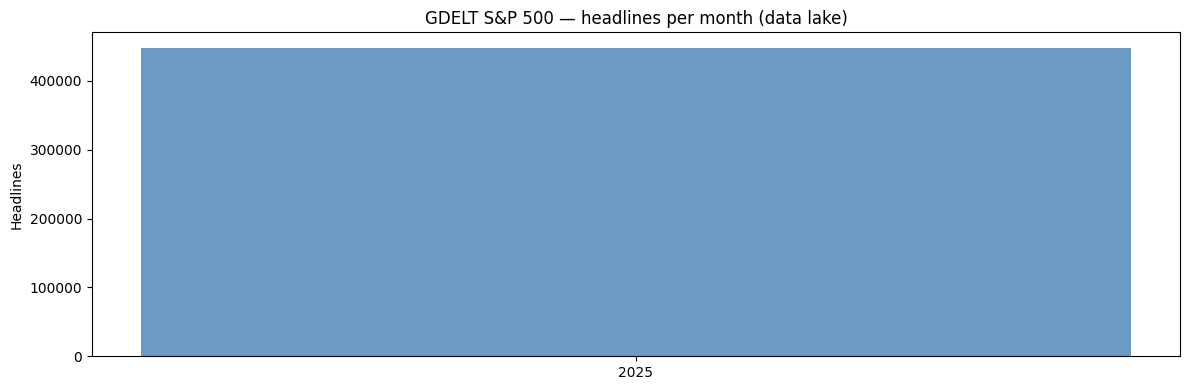

Months in data lake: 1
Date range: 2025-01-01 to 2025-01-01


In [16]:
monthly = (
    df_full.with_columns(pl.col("gkg_date").cast(pl.Date).dt.truncate("1mo").alias("month"))
    .group_by("month")
    .agg(pl.len().alias("n_headlines"))
    .sort("month")
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(
    monthly["month"].to_list(),
    monthly["n_headlines"].to_list(),
    width=25,
    color="steelblue",
    alpha=0.8,
)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_ylabel("Headlines")
ax.set_title("GDELT S&P 500 — headlines per month (data lake)")
fig.tight_layout()
plt.show()

print(f"Months in data lake: {monthly.height}")
print(f"Date range: {monthly['month'].min()} to {monthly['month'].max()}")

### Distinct S&P 500 companies per year

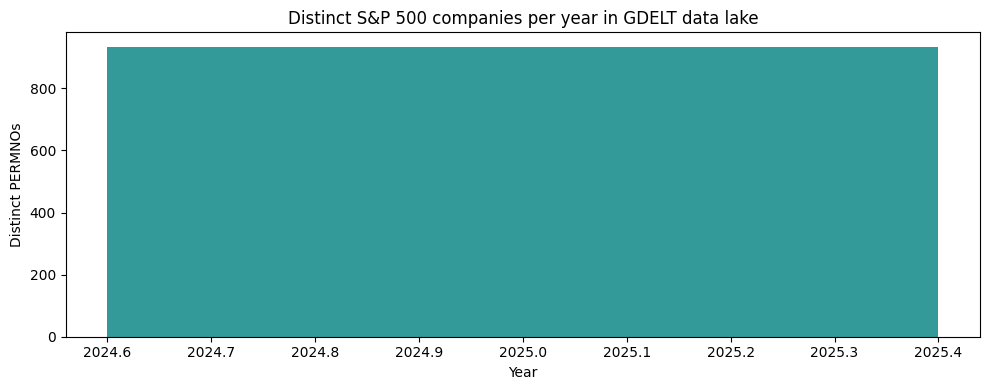

In [17]:
yearly_companies = (
    df_full.with_columns(pl.col("gkg_date").dt.year().alias("year"))
    .group_by("year")
    .agg(pl.col("permno").n_unique().alias("n_companies"))
    .sort("year")
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(
    yearly_companies["year"].to_list(),
    yearly_companies["n_companies"].to_list(),
    color="teal",
    alpha=0.8,
)
ax.set_xlabel("Year")
ax.set_ylabel("Distinct PERMNOs")
ax.set_title("Distinct S&P 500 companies per year in GDELT data lake")
fig.tight_layout()
plt.show()

---
## 7. Summary

**Filtering works but is noisy.** The BigQuery server-side JOIN reduces
GDELT from millions of raw articles to tens of thousands of S&P 500
matches per month. However, aggressive name normalization creates false
positives — especially for companies whose names reduce to common
phrases after suffix stripping (e.g., "UNITED STATES BANCORP" →
"united states").

**GDELT and RavenPack draw from different source ecosystems.** GDELT
covers the open web (~98%), while RavenPack is ~95% wire services.
Only ~7% of GDELT headlines match RavenPack on a per-headline basis.
However, GDELT's enormous daily volume (hundreds of thousands of
articles) means it actually covers a **larger fraction of the
RavenPack universe** than scraped newswires alone. Newswire headlines
match at a higher per-headline rate but have smaller total volume.
Both sources are combined in the final crosswalk for maximum coverage
(see notebook 03 for the per-source breakdown).

**The full data lake** shows consistent coverage from 2015 to present,
with hundreds of distinct S&P 500 companies matched per year.

---
## Bottom Line

In [18]:
pl.DataFrame({
    "metric": [
        "RP headlines matched",
        "NW headlines matched",
        "GDELT match rate",
        "Crosswalk pairs",
        "Date range",
    ],
    "value": [
        f"{_rp_match_rate:.1f}% ({_rp_matched_stories:,} / {_rp_total_stories:,})",
        f"{_nw_match_rate:.1f}% ({_nw_matched_urls:,} / {_nw_total_urls:,})",
        "~7% (different source ecosystems)",
        f"{len(_cw):,}",
        f"{_cw['date'].min()} to {_cw['date'].max()} ({_cw['date'].n_unique():,} dates)",
    ],
})

metric,value
str,str
"""RP headlines matched""","""2.9% (509,932 / 17,636,011)"""
"""NW headlines matched""","""22.5% (532,609 / 2,363,887)"""
"""GDELT match rate""","""~7% (different source ecosyste…"
"""Crosswalk pairs""","""533,265"""
"""Date range""","""2010-03-18 to 2026-02-28 (3,83…"
